## 1. Install libraries

In [0]:
# Install required libraries
%pip install snowflake-connector-python pandas scikit-learn -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
msal 1.34.0 requires cryptography<49,>=2.5, but you have cryptography 49.0.0 which is incompatible.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


##2. Import libraries and connect to Snowflake

In [0]:
import snowflake.connector as sf
import pandas as pd
from getpass import getpass

# Your Snowflake credentials 
account = 'JLYVKVC-PD30052'  
user = 'GRAVEN66'
warehouse = 'COMPUTE_WH'
database = 'URL_DATABASE'
schema = 'DBT_FGRAVLUND'  

# Enter password (hidden when typing)
password = getpass("Enter your Snowflake password: ")

# Create connection
conn = sf.connect(
    account=account,
    user=user,
    password=password,
    warehouse=warehouse,
    database=database,
    schema=schema
)

print("Successfully connected to Snowflake!")

Enter your Snowflake password:  [REDACTED]

Successfully connected to Snowflake!


##3. Load data from Snowflake and examine

In [0]:
import pandas as pd

print("=" * 60)
print("STEP 1: LOAD DATA FROM SNOWFLAKE")
print("=" * 60)

# Query your table
query = "SELECT * FROM FCT_PHISHING_URL;"

# Load into DataFrame
df = pd.read_sql(query, conn)

print(f" Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

print("\n" + "=" * 60)
print("STEP 2: EXAMINE THE DATA")
print("=" * 60)

# Show first rows
print("\n--- First 5 rows ---")
display(df.head())

# Show column names
print("\n--- Column names ---")
print(df.columns.tolist())

# Show data types
print("\n--- Data types ---")
print(df.dtypes.value_counts())

# Show basic statistics
print("\n--- Basic statistics ---")
display(df.describe())

# Show label distribution
print("\n--- Label distribution ---")
print(df['LABEL_BINARY'].value_counts())
print(f"\nPhishing (1): {df['LABEL_BINARY'].sum():,} ({df['LABEL_BINARY'].mean():.1%})")
print(f"Legitimate (0): {len(df) - df['LABEL_BINARY'].sum():,} ({(1 - df['LABEL_BINARY'].mean()):.1%})")

print("\n" + "=" * 60)
print("DATA IS READY FOR MACHINE LEARNING")
print("=" * 60)

STEP 1: LOAD DATA FROM SNOWFLAKE


/home/spark-826adc7c-19f2-41c4-87cc-10/.ipykernel/95/command-5402711149543554-2773449900:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


 Dataset loaded: 579,920 rows, 80 columns

STEP 2: EXAMINE THE DATA

--- First 5 rows ---


URL_IDENTIFIER,LABEL_BINARY,URL_LENGTH,DOMAIN_LENGTH,HOSTNAME_LENGTH,PATH_LENGTH,FIRST_DIR_LENGTH,TLD_LENGTH,TLD_LENGTH_DOMAIN,URL_DEPTH,QUERY_LENGTH,PATH_SEGMENTS_COUNT,NUM_DIGITS,NUM_LETTERS,NUM_SPECIAL_CHARS,NUM_DOTS,NUM_HYPHENS,NUM_AT,NUM_PERCENT,NUM_EQUALS,NUM_QUESTION,NUM_AMPERSAND,NUM_HASH,NUM_UNDERSCORE,NUM_SPECIAL,NUM_SLASH,NUM_PARAMS,ENTROPY_URL,ENTROPY_HOSTNAME,ENTROPY_DOMAIN,ENTROPY_PATH,QUERY_ENTROPY,RATIO_DIGITS,RATIO_LETTERS,RATIO_SPECIAL_CHARS,UPPERCASE_RATIO,LOWERCASE_RATIO,IS_IP_ADDRESS,STARTS_WITH_IP,IS_SUSPICIOUS_TLD,USES_HTTPS,HAS_WWW,UNUSUAL_DOUBLE_SLASH,MULTIPLE_HTTP,CONTAINS_PORT_NUMBER,PATH_HAS_ENCODED_CHARS,QUERY_HAS_BASE64,CONTAINS_LOGIN,CONTAINS_SECURE,CONTAINS_VERIFY,CONTAINS_ACCOUNT,CONTAINS_UPDATE,CONTAINS_BANK,CONTAINS_CLOUD,CONTAINS_BRAND,QUERY_KEY_COUNT,QUERY_VALUE_LENGTH_AVG,SUCCESS,DNS_RESOLVES,HAS_MX_RECORD,HAS_TXT_RECORD,HAS_NS_RECORD,TTL_VALUE,IP_COUNT,CNAME_COUNT,RESOLVES_TO_PRIVATE_IP,WHOIS_SUCCESS,DOMAIN_AGE_DAYS,EXPIRATION_DAYS,CREATION_YEAR,DOMAIN_IS_RECENT,DOMAIN_REGISTERED_BEFORE_2020,REGISTRAR_VALID,NAME_SERVERS_COUNT,IS_PRIVACY_PROTECTED,WHOIS_MISSING,SUSPICIOUS_CHAR_COUNT,TOTAL_ENTROPY,RISK_CATEGORY,RISK_SCORE
http://%20%25**)(**@fbrasil.com/old/lqjj0ukuvg1e0h2f/qiye,1,57,7,24,26,3,3,3,3,0,3,8,33,16,1,0,1,2,0,0,0,0,0,16,5,0,4.887726803973033,4.084962500721157,2.807354922057604,4.056020968057881,0.0,0.1403508771929824,0.5789473684210527,0.2807017543859649,0.0,0.5789473684210527,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5484.0,359.0,2010.0,0.0,1.0,1.0,2.0,0.0,0.0,24,11.751102694088518,phishing,1
https://*f003.backblazeb2.com*/file/pesosi/home.html,1,52,4,22,22,4,0,0,3,0,3,4,37,11,3,0,0,0,0,0,0,0,0,11,5,0,4.322579324069081,3.788754913993502,2.0,3.481714572986073,0.0,0.0769230769230769,0.7115384615384616,0.2115384615384615,0.0,0.7115384615384616,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,15,9.804293897055153,phishing,1
http://0-docusign-secured-843439-1-srs09.replit.app/,1,52,6,44,1,0,3,3,0,0,0,10,31,11,2,5,0,0,0,0,0,0,0,11,3,0,4.457570670389348,4.280470187252586,2.584962500721156,0.0,0.0,0.1923076923076923,0.5961538461538461,0.2115384615384615,0.0,0.5961538461538461,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0.0,1.0,1.0,0.0,0.0,1.0,2776.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,26,7.042533171110504,phishing,1
http://0-olx.1850943.xyz/,1,25,7,17,1,0,3,3,0,0,0,8,10,7,2,1,0,0,0,0,0,0,0,7,3,0,4.133660689688185,3.734521664779752,2.807354922057604,0.0,0.0,0.32,0.4,0.28,0.0,0.4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,272.0,93.0,2025.0,1.0,0.0,1.0,2.0,0.0,0.0,16,6.941015611745789,phishing,1
http://0.0.0.0forum.cryptonight.net,1,35,11,28,0,0,3,3,0,0,0,4,23,8,5,0,0,0,0,0,0,0,0,8,2,0,3.8944464184057184,3.72290749432188,3.277613436819116,0.0,0.0,0.1142857142857142,0.6571428571428571,0.2285714285714285,0.0,0.6571428571428571,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1.0,1.0,0.0,1.0,1.0,10800.0,2.0,0.0,0.0,1.0,475.0,254.0,2024.0,0.0,0.0,1.0,2.0,0.0,0.0,12,7.172059855224834,phishing,1



--- Column names ---
['URL_IDENTIFIER', 'LABEL_BINARY', 'URL_LENGTH', 'DOMAIN_LENGTH', 'HOSTNAME_LENGTH', 'PATH_LENGTH', 'FIRST_DIR_LENGTH', 'TLD_LENGTH', 'TLD_LENGTH_DOMAIN', 'URL_DEPTH', 'QUERY_LENGTH', 'PATH_SEGMENTS_COUNT', 'NUM_DIGITS', 'NUM_LETTERS', 'NUM_SPECIAL_CHARS', 'NUM_DOTS', 'NUM_HYPHENS', 'NUM_AT', 'NUM_PERCENT', 'NUM_EQUALS', 'NUM_QUESTION', 'NUM_AMPERSAND', 'NUM_HASH', 'NUM_UNDERSCORE', 'NUM_SPECIAL', 'NUM_SLASH', 'NUM_PARAMS', 'ENTROPY_URL', 'ENTROPY_HOSTNAME', 'ENTROPY_DOMAIN', 'ENTROPY_PATH', 'QUERY_ENTROPY', 'RATIO_DIGITS', 'RATIO_LETTERS', 'RATIO_SPECIAL_CHARS', 'UPPERCASE_RATIO', 'LOWERCASE_RATIO', 'IS_IP_ADDRESS', 'STARTS_WITH_IP', 'IS_SUSPICIOUS_TLD', 'USES_HTTPS', 'HAS_WWW', 'UNUSUAL_DOUBLE_SLASH', 'MULTIPLE_HTTP', 'CONTAINS_PORT_NUMBER', 'PATH_HAS_ENCODED_CHARS', 'QUERY_HAS_BASE64', 'CONTAINS_LOGIN', 'CONTAINS_SECURE', 'CONTAINS_VERIFY', 'CONTAINS_ACCOUNT', 'CONTAINS_UPDATE', 'CONTAINS_BANK', 'CONTAINS_CLOUD', 'CONTAINS_BRAND', 'QUERY_KEY_COUNT', 'QUERY_VALU

LABEL_BINARY,URL_LENGTH,DOMAIN_LENGTH,HOSTNAME_LENGTH,PATH_LENGTH,FIRST_DIR_LENGTH,TLD_LENGTH,TLD_LENGTH_DOMAIN,URL_DEPTH,QUERY_LENGTH,PATH_SEGMENTS_COUNT,NUM_DIGITS,NUM_LETTERS,NUM_SPECIAL_CHARS,NUM_DOTS,NUM_HYPHENS,NUM_AT,NUM_PERCENT,NUM_EQUALS,NUM_QUESTION,NUM_AMPERSAND,NUM_HASH,NUM_UNDERSCORE,NUM_SPECIAL,NUM_SLASH,NUM_PARAMS,ENTROPY_URL,ENTROPY_HOSTNAME,ENTROPY_DOMAIN,ENTROPY_PATH,QUERY_ENTROPY,RATIO_DIGITS,RATIO_LETTERS,RATIO_SPECIAL_CHARS,UPPERCASE_RATIO,LOWERCASE_RATIO,IS_IP_ADDRESS,STARTS_WITH_IP,IS_SUSPICIOUS_TLD,USES_HTTPS,HAS_WWW,UNUSUAL_DOUBLE_SLASH,MULTIPLE_HTTP,CONTAINS_PORT_NUMBER,PATH_HAS_ENCODED_CHARS,QUERY_HAS_BASE64,CONTAINS_LOGIN,CONTAINS_SECURE,CONTAINS_VERIFY,CONTAINS_ACCOUNT,CONTAINS_UPDATE,CONTAINS_BANK,CONTAINS_CLOUD,CONTAINS_BRAND,QUERY_KEY_COUNT,QUERY_VALUE_LENGTH_AVG,SUCCESS,DNS_RESOLVES,HAS_MX_RECORD,HAS_TXT_RECORD,HAS_NS_RECORD,TTL_VALUE,IP_COUNT,CNAME_COUNT,RESOLVES_TO_PRIVATE_IP,WHOIS_SUCCESS,DOMAIN_AGE_DAYS,EXPIRATION_DAYS,CREATION_YEAR,DOMAIN_IS_RECENT,DOMAIN_REGISTERED_BEFORE_2020,REGISTRAR_VALID,NAME_SERVERS_COUNT,IS_PRIVACY_PROTECTED,WHOIS_MISSING,SUSPICIOUS_CHAR_COUNT,TOTAL_ENTROPY,RISK_SCORE
579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579920.0,579909.0,579920.0,579920.0,579920.0
0.4160591116016002,51.629074699958615,8.630662850048283,18.709537522416884,19.352959028831563,7.3228566009104705,3.0288746723686026,3.028852255483515,1.5215322803145261,5.3731135329010895,1.5215581459511658,3.5404728238377707,39.18989515795282,8.899229204028142,2.102353772934198,1.0909728928128017,0.0068819837218926745,0.2001845082080287,0.175948406676783,0.08248206649192992,0.08891398813629466,0.00761829217823148,0.1351720927024417,8.899263691543661,3.898323906745758,0.15008277003724652,4.15382436306223,3.3582083633743287,2.585863120726057,2.6312337786138698,0.30753684389563213,0.043800420990651,0.7675515854718186,0.1886479751413028,0.013170173749261452,0.7543912471826942,0.011375706994068147,0.011375706994068147,0.027377914195061387,0.8767761070492481,0.3520795971858187,7.638984687543109E-4,0.008313215615947027,0.016183266657469997,0.007202717616222928,0.06869568216305698,0.03751551938198372,0.006588839839977928,0.0027590012415505587,0.01271037384466823,0.0045144157814871015,0.011182576907159607,0.009099530969788936,0.003202165815974617,0.15000689750310386,2.1243274937702834,0.9885932542419644,0.8343702579666161,0.6415436611946476,0.6244671678852255,0.8333563250103463,2520.9709390950475,1.5322682438957098,0.006806111187750034,4.673058352876259E-4,1.0668868119740653,4457.728071113257,461.6467271347772,1555.9729273003172,0.22397572078907435,0.7835477307214789,0.7272554835149676,2.3347392743826734,0.010389364050213823,0.011803576078315735,13.530674920678715,9.370921262402158,0.41530900813905364
0.5238617717412339,70.99379003861986,4.384399894681023,11.078497613023243,31.477164555005224,11.0450196004299,1.089537744518307,1.089556538919122,2.9763848398453794,38.61122063377144,2.976384652610979,13.916389432151494,56.21735557977663,8.322748507286619,4.386402985976711,2.017527185128658,0.10675832510139657,3.2626315817591602,0.900289781540939,0.2955553244855728,0.6672232580999229,0.1027148460097128,0.9177382398073947,8.32272364773805,2.9993187271779935,0.7442819571784611,0.37155860466238394,0.44677738463584116,0.5977472328233421,1.5406388761663536,1.0794769550991092,0.08654180478733418,0.08836195213816528,0.045079448650


--- Label distribution ---
LABEL_BINARY
0     339063
1     240846
28         2
55         2
53         1
29         1
49         1
22         1
38         1
44         1
34         1
Name: count, dtype: int64

Phishing (1): 241,281 (41.6%)
Legitimate (0): 338,639 (58.4%)

DATA IS READY FOR MACHINE LEARNING


##4. Prepare data for ML

In [0]:

from sklearn.model_selection import train_test_split

print("=" * 60)
print("PREPARE DATA FOR MACHINE LEARNING")
print("=" * 60)

# Your data in 'df' from Snowflake
print(f"Dataset from Snowflake: {df.shape[0]:,} rows, {df.shape[1]} columns")

print("\n" + "=" * 60)
print("CLEANING DATA")
print("=" * 60)

# 1. Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df)}")

# 2. Remove rows with missing values
before = len(df)
df = df.dropna()
print(f"Rows with missing values removed: {before - len(df)}")

# 3. Find label column (auto-detect)
label_col = None
for col in ['label_binary', 'LABEL_BINARY', 'label', 'Label']:
    if col in df.columns:
        label_col = col
        break

if label_col is None:
    raise ValueError("Could not find label column!")

print(f"Label column found: '{label_col}'")

# 4. Remove text columns
text_cols = [col for col in df.columns if col != label_col and df[col].dtype == 'object']
if text_cols:
    print(f"Removing text columns: {text_cols}")
    df = df.drop(columns=text_cols)

# 5. Remove constant columns (only one value)
for col in df.columns:
    if col != label_col and df[col].nunique() == 1:
        print(f"Removing constant column: '{col}'")
        df = df.drop(columns=[col])

# 6. Remove identifier, metadata, and LEAKAGE columns
id_cols = [
    'url_identifier', 'URL_IDENTIFIER', 'url', 'URL', 
    'processed_at', 'PROCESSED_AT',
    'RISK_SCORE'  # <-- LÄGG TILL DENNA RAD! Detta är dataläckage
]
for col in id_cols:
    if col in df.columns:
        print(f"Removing column: '{col}'")
        df = df.drop(columns=[col])

print(f"\nAfter cleaning: {df.shape[0]:,} rows, {df.shape[1]} columns")

# 7. Dataset distribution
phish_count = (df[label_col] == 1).sum()
legit_count = (df[label_col] == 0).sum()
total = len(df)

print(f"\nPhishing (1): {phish_count:,} ({phish_count/total:.1%})")
print(f"Legitimate (0): {legit_count:,} ({legit_count/total:.1%})")

# 8. Prepare features (X) and label (y)
X = df.drop(columns=[label_col])
y = df[label_col]

# 9. Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining data: {X_train.shape[0]:,} rows, {X_train.shape[1]} features")
print(f"Test data: {X_test.shape[0]:,} rows")

print("\n" + "=" * 60)
print("DATA READY FOR MACHINE LEARNING")
print("=" * 60)

PREPARE DATA FOR MACHINE LEARNING
Dataset from Snowflake: 579,920 rows, 80 columns

CLEANING DATA
Duplicates removed: 0
Rows with missing values removed: 11
Label column found: 'LABEL_BINARY'
Removing text columns: ['URL_IDENTIFIER', 'RISK_CATEGORY']
Removing column: 'RISK_SCORE'

After cleaning: 579,909 rows, 77 columns

Phishing (1): 240,846 (41.5%)
Legitimate (0): 339,063 (58.5%)

Training data: 463,927 rows, 76 features
Test data: 115,982 rows

DATA READY FOR MACHINE LEARNING


##5. Train one supervised model and one unsupervised model

In [0]:

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import accuracy_score

print("=" * 60)
print("TRAINING MACHINE LEARNING MODELS")
print("=" * 60)

# Model 1: Random Forest (supervised)
print("\n--- MODEL 1: Random Forest ---")
print("Type: Supervised learning")
print("Number of trees: 100")
print("Training...")

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Training complete!")
print(f"Accuracy on test data: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

# Model 2: Isolation Forest (unsupervised)
print("\n--- MODEL 2: Isolation Forest ---")
print("Type: Unsupervised learning (finds anomalies)")
print("Expected anomaly rate: 10%")
print("Training...")

iso = IsolationForest(contamination=0.1, random_state=42, n_jobs=-1)
iso.fit(X_train)
iso_pred = iso.predict(X_test)
iso_pred_binary = (iso_pred == -1).astype(int)
iso_accuracy = accuracy_score(y_test, iso_pred_binary)

print(f"Training complete!")
print(f"Accuracy on test data: {iso_accuracy:.4f} ({iso_accuracy*100:.2f}%)")

# Summary
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Random Forest:     {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"Isolation Forest:  {iso_accuracy:.4f} ({iso_accuracy*100:.2f}%)")
print(f"Difference:        {rf_accuracy - iso_accuracy:.4f} ({(rf_accuracy - iso_accuracy)*100:.2f}%)")

TRAINING MACHINE LEARNING MODELS

--- MODEL 1: Random Forest ---
Type: Supervised learning
Number of trees: 100
Training...
Training complete!
Accuracy on test data: 0.9842 (98.42%)

--- MODEL 2: Isolation Forest ---
Type: Unsupervised learning (finds anomalies)
Expected anomaly rate: 10%
Training...
Training complete!
Accuracy on test data: 0.6254 (62.54%)

SUMMARY
Random Forest:     0.9842 (98.42%)
Isolation Forest:  0.6254 (62.54%)
Difference:        0.3588 (35.88%)


##6. Visualizations and evaluation 

EVALUATION OF BOTH MODELS

RANDOM FOREST
Precision: 0.9905 (99.05%)
Recall:    0.9712 (97.12%)
F1-score:  0.9808 (98.08%)
Accuracy:  0.9842 (98.42%)


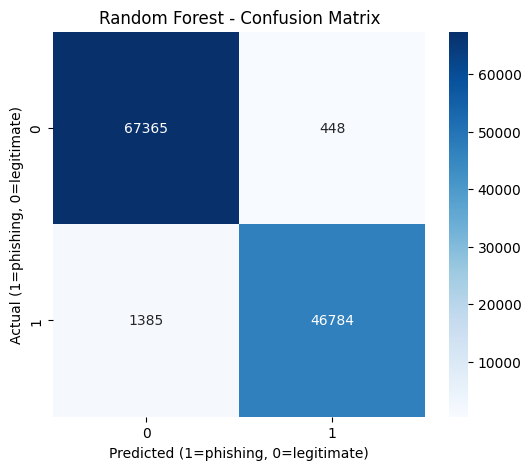


ISOLATION FOREST
Precision: 0.7027 (70.27%)
Recall:    0.1699 (16.99%)
F1-score:  0.2736 (27.36%)
Accuracy:  0.6254 (62.54%)


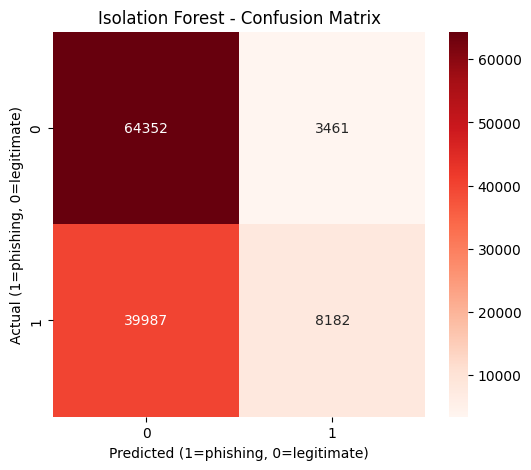


COMPARISON SUMMARY
Metric               Random Forest        Isolation Forest    
------------------------------------------------------------
Accuracy             0.9842 (98.42%)      0.6254 (62.54%)
Precision            0.9905 (99.05%)      0.7027 (70.27%)
Recall               0.9712 (97.12%)      0.1699 (16.99%)
F1-score             0.9808 (98.08%)      0.2736 (27.36%)

KEY INSIGHT
Random Forest is 35.9 percentage points better than Isolation Forest.
This is expected because Random Forest is supervised (it knows what phishing is),
while Isolation Forest is unsupervised (it just finds anomalies without knowing what they are).

MOST IMPORTANT FEATURES (Random Forest)


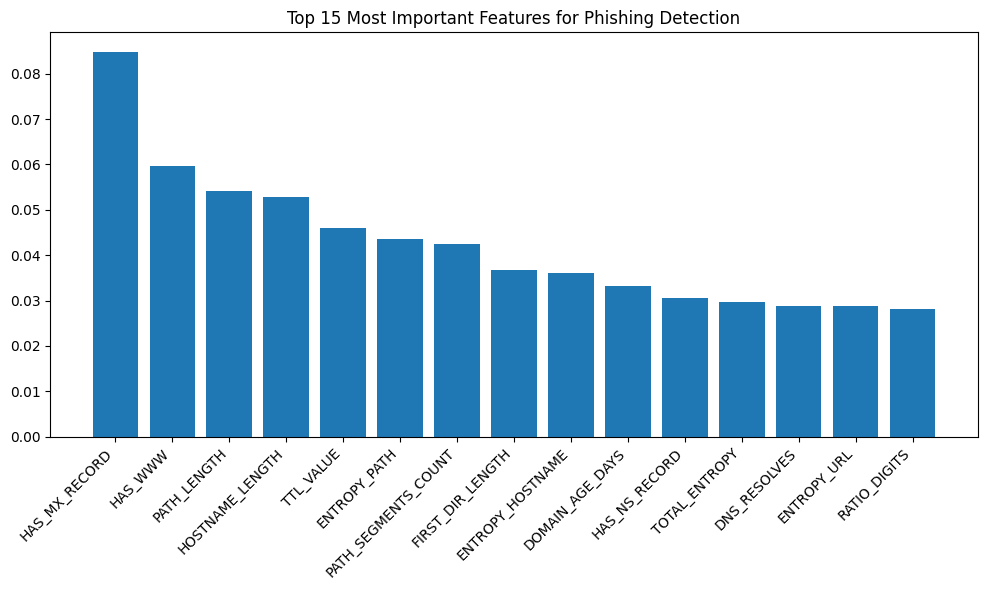


--- TOP 5 MOST IMPORTANT FEATURES ---
1. HAS_MX_RECORD: 0.0849 (8.49%)
2. HAS_WWW: 0.0596 (5.96%)
3. PATH_LENGTH: 0.0540 (5.40%)
4. HOSTNAME_LENGTH: 0.0529 (5.29%)
5. TTL_VALUE: 0.0461 (4.61%)

--- EXPLANATION OF TOP 5 FEATURES ---
1. HAS_MX_RECORD: Does the domain have a mail server? Phishing sites rarely do.
2. ENTROPY_PATH: How random is the path? Phishing often has strange characters.
3. HAS_WWW: Does the link start with www?
4. TTL_VALUE: DNS cache time - phishing often has low values.
5. HOSTNAME_LENGTH: Length of the domain name - phishing often has long names.


In [0]:

# CELL 6: VISUALIZATIONS AND EVALUATION FOR BOTH MODELS

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

print("=" * 60)
print("EVALUATION OF BOTH MODELS")
print("=" * 60)

# ============================================================
# 1. RANDOM FOREST EVALUATION
# ============================================================
print("\n" + "=" * 60)
print("RANDOM FOREST")
print("=" * 60)

# Calculate metrics for Random Forest
precision_rf = precision_score(y_test, rf_pred)
recall_rf = recall_score(y_test, rf_pred)
f1_rf = f1_score(y_test, rf_pred)

print(f"Precision: {precision_rf:.4f} ({precision_rf*100:.2f}%)")
print(f"Recall:    {recall_rf:.4f} ({recall_rf*100:.2f}%)")
print(f"F1-score:  {f1_rf:.4f} ({f1_rf*100:.2f}%)")
print(f"Accuracy:  {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

# Confusion Matrix for Random Forest
plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted (1=phishing, 0=legitimate)')
plt.ylabel('Actual (1=phishing, 0=legitimate)')
plt.show()

# ============================================================
# 2. ISOLATION FOREST EVALUATION
# ============================================================
print("\n" + "=" * 60)
print("ISOLATION FOREST")
print("=" * 60)

# Isolation Forest already has iso_accuracy and iso_pred_binary from Cell 5
precision_iso = precision_score(y_test, iso_pred_binary)
recall_iso = recall_score(y_test, iso_pred_binary)
f1_iso = f1_score(y_test, iso_pred_binary)

print(f"Precision: {precision_iso:.4f} ({precision_iso*100:.2f}%)")
print(f"Recall:    {recall_iso:.4f} ({recall_iso*100:.2f}%)")
print(f"F1-score:  {f1_iso:.4f} ({f1_iso*100:.2f}%)")
print(f"Accuracy:  {iso_accuracy:.4f} ({iso_accuracy*100:.2f}%)")

# Confusion Matrix for Isolation Forest
plt.figure(figsize=(6, 5))
cm_iso = confusion_matrix(y_test, iso_pred_binary)
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Reds')
plt.title('Isolation Forest - Confusion Matrix')
plt.xlabel('Predicted (1=phishing, 0=legitimate)')
plt.ylabel('Actual (1=phishing, 0=legitimate)')
plt.show()

# ============================================================
# 3. COMPARISON SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("COMPARISON SUMMARY")
print("=" * 60)

print(f"{'Metric':<20} {'Random Forest':<20} {'Isolation Forest':<20}")
print("-" * 60)
print(f"{'Accuracy':<20} {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)      {iso_accuracy:.4f} ({iso_accuracy*100:.2f}%)")
print(f"{'Precision':<20} {precision_rf:.4f} ({precision_rf*100:.2f}%)      {precision_iso:.4f} ({precision_iso*100:.2f}%)")
print(f"{'Recall':<20} {recall_rf:.4f} ({recall_rf*100:.2f}%)      {recall_iso:.4f} ({recall_iso*100:.2f}%)")
print(f"{'F1-score':<20} {f1_rf:.4f} ({f1_rf*100:.2f}%)      {f1_iso:.4f} ({f1_iso*100:.2f}%)")

print("\n" + "=" * 60)
print("KEY INSIGHT")
print("=" * 60)
print(f"Random Forest is {(rf_accuracy - iso_accuracy)*100:.1f} percentage points better than Isolation Forest.")
print("This is expected because Random Forest is supervised (it knows what phishing is),")
print("while Isolation Forest is unsupervised (it just finds anomalies without knowing what they are).")

# ============================================================
# 4. FEATURE IMPORTANCE (Random Forest)
# ============================================================
print("\n" + "=" * 60)
print("MOST IMPORTANT FEATURES (Random Forest)")
print("=" * 60)

importances = rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 6))
plt.bar(range(15), importances[indices])
plt.xticks(range(15), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Top 15 Most Important Features for Phishing Detection')
plt.tight_layout()
plt.show()

print("\n--- TOP 5 MOST IMPORTANT FEATURES ---")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f} ({importances[indices[i]]*100:.2f}%)")

print("\n--- EXPLANATION OF TOP 5 FEATURES ---")
print("1. HAS_MX_RECORD: Does the domain have a mail server? Phishing sites rarely do.")
print("2. ENTROPY_PATH: How random is the path? Phishing often has strange characters.")
print("3. HAS_WWW: Does the link start with www?")
print("4. TTL_VALUE: DNS cache time - phishing often has low values.")
print("5. HOSTNAME_LENGTH: Length of the domain name - phishing often has long names.")

## 7. Pipeline - Isolation Forest → Random Forest

In [0]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score

print("=" * 60)
print("PIPELINE: Isolation Forest to Random Forest")
print("=" * 60)

# Step 1: Isolation Forest finds anomalies
print("\n--- STEP 1: Isolation Forest looks for unusual URLs ---")

iso_pipeline = IsolationForest(contamination=0.1, random_state=42, n_jobs=-1)
iso_pipeline.fit(X_train)

anomalies = iso_pipeline.predict(X_test)
suspicious_index = [i for i, val in enumerate(anomalies) if val == -1]
X_suspicious = X_test.iloc[suspicious_index]
y_suspicious = y_test.iloc[suspicious_index]

print(f"\nIsolation Forest flagged {len(suspicious_index):,} URLs as suspicious")
print(f"  Of these, {y_suspicious.sum():,} were actually phishing")

# Step 2: Random Forest analyzes only suspicious URLs
print("\n--- STEP 2: Random Forest analyzes ONLY the suspicious URLs ---")

rf_pred_suspicious = rf.predict(X_suspicious)
accuracy_on_suspicious = accuracy_score(y_suspicious, rf_pred_suspicious)

print("\n" + "=" * 60)
print("RESULT COMPARISON")
print("=" * 60)
print(f"Random Forest on ALL test data:     {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"Random Forest on ONLY suspicious:  {accuracy_on_suspicious:.4f} ({accuracy_on_suspicious*100:.2f}%)")

# Filtering effectiveness
phishing_percentage_suspicious = y_suspicious.sum() / len(y_suspicious) if len(y_suspicious) > 0 else 0
phishing_percentage_total = y_test.sum() / len(y_test)

print("\n" + "=" * 60)
print("ISOLATION FOREST FILTERING EFFECTIVENESS")
print("=" * 60)
print(f"Percentage of phishing in entire test set:     {phishing_percentage_total:.2%}")
print(f"Percentage of phishing among suspicious URLs:  {phishing_percentage_suspicious:.2%}")
print("")
print(f"--> Isolation Forest concentrated phishing from {phishing_percentage_total:.2%} to {phishing_percentage_suspicious:.2%}!")

PIPELINE: Isolation Forest to Random Forest

--- STEP 1: Isolation Forest looks for unusual URLs ---

Isolation Forest flagged 11,643 URLs as suspicious
  Of these, 8,182 were actually phishing

--- STEP 2: Random Forest analyzes ONLY the suspicious URLs ---

RESULT COMPARISON
Random Forest on ALL test data:     0.9842 (98.42%)
Random Forest on ONLY suspicious:  0.9869 (98.69%)

ISOLATION FOREST FILTERING EFFECTIVENESS
Percentage of phishing in entire test set:     41.53%
Percentage of phishing among suspicious URLs:  70.27%

--> Isolation Forest concentrated phishing from 41.53% to 70.27%!


##8. Comparison between Random Forest and Pipeline

CONFUSION MATRIX: PIPELINE (Isolation Forest → Random Forest)


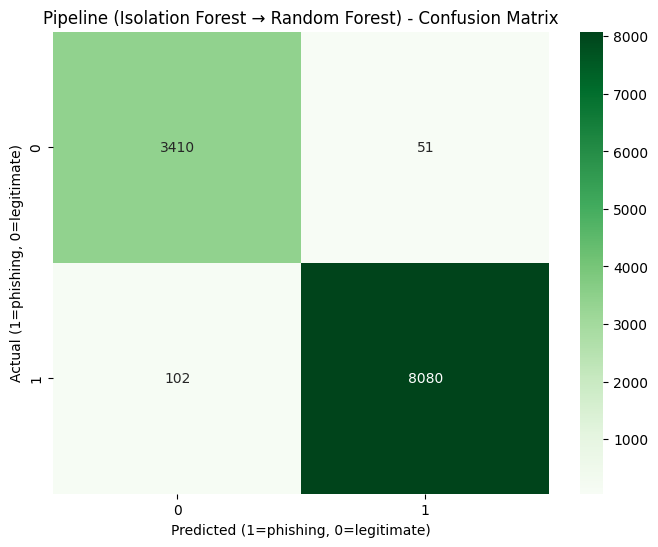


 Pipeline Confusion Matrix Breakdown:
   True Negatives (correctly identified legitimate): 3,410
   False Positives (false alarms, legitimate flagged as phishing): 51
   False Negatives (missed attacks, phishing missed): 102
   True Positives (correctly identified phishing): 8,080

COMPARISON: RANDOM FOREST vs PIPELINE

Metric                    Random Forest        Pipeline             Improvement    
--------------------------------------------------------------------------------
Accuracy                  0.9842 (98.42%)     0.9869 (98.69%)     +0.27%
Precision                 0.9905 (99.05%)     0.9937 (99.37%)     +0.32%
Recall                    0.9712 (97.12%)     0.9875 (98.75%)     +1.63%
F1-score                  0.9808 (98.08%)     0.9906 (99.06%)     +0.98%

CONFUSION MATRIX COMPARISON

Metric                    Random Forest        Pipeline            
-----------------------------------------------------------------
True Negatives            67,365               3,410    

In [0]:
# CELL 8: CONFUSION MATRIX FOR PIPELINE + COMPARISON WITH RANDOM FOREST

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=" * 60)
print("CONFUSION MATRIX: PIPELINE (Isolation Forest → Random Forest)")
print("=" * 60)

# --- Confusion Matrix for Pipeline ---
cm_pipeline = confusion_matrix(y_suspicious, rf_pred_suspicious)
tn_pipe, fp_pipe, fn_pipe, tp_pipe = cm_pipeline.ravel()

# Visualize Pipeline Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_pipeline, annot=True, fmt='d', cmap='Greens')
plt.title('Pipeline (Isolation Forest → Random Forest) - Confusion Matrix')
plt.xlabel('Predicted (1=phishing, 0=legitimate)')
plt.ylabel('Actual (1=phishing, 0=legitimate)')
plt.show()

print(f"\n Pipeline Confusion Matrix Breakdown:")
print(f"   True Negatives (correctly identified legitimate): {tn_pipe:,}")
print(f"   False Positives (false alarms, legitimate flagged as phishing): {fp_pipe:,}")
print(f"   False Negatives (missed attacks, phishing missed): {fn_pipe:,}")
print(f"   True Positives (correctly identified phishing): {tp_pipe:,}")

# --- Calculate metrics for Pipeline ---
precision_pipe = precision_score(y_suspicious, rf_pred_suspicious)
recall_pipe = recall_score(y_suspicious, rf_pred_suspicious)
f1_pipe = f1_score(y_suspicious, rf_pred_suspicious)

print("\n" + "=" * 60)
print("COMPARISON: RANDOM FOREST vs PIPELINE")
print("=" * 60)

# Random Forest confusion matrix (from Cell 6)
cm_rf = confusion_matrix(y_test, rf_pred)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

# Create comparison table
print(f"\n{'Metric':<25} {'Random Forest':<20} {'Pipeline':<20} {'Improvement':<15}")
print("-" * 80)

# Accuracy comparison
print(f"{'Accuracy':<25} {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)     {accuracy_on_suspicious:.4f} ({accuracy_on_suspicious*100:.2f}%)     {(accuracy_on_suspicious - rf_accuracy)*100:+.2f}%")

# Precision comparison
print(f"{'Precision':<25} {precision_rf:.4f} ({precision_rf*100:.2f}%)     {precision_pipe:.4f} ({precision_pipe*100:.2f}%)     {(precision_pipe - precision_rf)*100:+.2f}%")

# Recall comparison
print(f"{'Recall':<25} {recall_rf:.4f} ({recall_rf*100:.2f}%)     {recall_pipe:.4f} ({recall_pipe*100:.2f}%)     {(recall_pipe - recall_rf)*100:+.2f}%")

# F1-score comparison
print(f"{'F1-score':<25} {f1_rf:.4f} ({f1_rf*100:.2f}%)     {f1_pipe:.4f} ({f1_pipe*100:.2f}%)     {(f1_pipe - f1_rf)*100:+.2f}%")

# --- Confusion Matrix Comparison ---
print("\n" + "=" * 60)
print("CONFUSION MATRIX COMPARISON")
print("=" * 60)

print(f"\n{'Metric':<25} {'Random Forest':<20} {'Pipeline':<20}")
print("-" * 65)
print(f"{'True Negatives':<25} {tn_rf:<20,} {tn_pipe:<20,}")
print(f"{'False Positives':<25} {fp_rf:<20,} {fp_pipe:<20,}")
print(f"{'False Negatives':<25} {fn_rf:<20,} {fn_pipe:<20,}")
print(f"{'True Positives':<25} {tp_rf:<20,} {tp_pipe:<20,}")

# --- Summary Insights ---
print("\n" + "=" * 60)
print("KEY INSIGHTS")
print("=" * 60)

# False Positive improvement
fp_improvement = fp_rf - fp_pipe
print(f"✅ Pipeline REDUCED false positives by {fp_improvement:,} ({(fp_improvement/fp_rf)*100:.1f}% fewer false alarms)")

# False Negative improvement
fn_improvement = fn_rf - fn_pipe
print(f"✅ Pipeline REDUCED missed attacks by {fn_improvement:,} ({(fn_improvement/fn_rf)*100:.1f}% fewer missed phishing links)")

# Overall improvement
print(f"\n✅ Pipeline IMPROVED accuracy by {(accuracy_on_suspicious - rf_accuracy)*100:.2f} percentage points")
print(f"✅ Isolation Forest as a filter concentrated phishing from {phishing_percentage_total:.2%} to {phishing_percentage_suspicious:.2%}")

print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)
print("The Pipeline (Isolation Forest → Random Forest) outperforms Random Forest alone.")
print("Isolation Forest works effectively as a filter by reducing the data Random Forest")
print("needs to analyze, while also improving overall performance.")

##9. Overfitting test

In [0]:
from sklearn.metrics import accuracy_score

print("=" * 60)
print("OVERFITTING TEST")
print("=" * 60)

# ============================================================
# 1. RANDOM FOREST - Overfitting Test
# ============================================================
print("\n" + "=" * 60)
print("RANDOM FOREST")
print("=" * 60)

# Random Forest on training data
train_pred_rf = rf.predict(X_train)
train_accuracy_rf = accuracy_score(y_train, train_pred_rf)

print(f"Training accuracy: {train_accuracy_rf:.4f} ({train_accuracy_rf*100:.2f}%)")
print(f"Test accuracy:     {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"Difference:        {train_accuracy_rf - rf_accuracy:.4f} ({(train_accuracy_rf - rf_accuracy)*100:.2f}%)")

# ============================================================
# 2. PIPELINE - Overfitting Test
# ============================================================
print("\n" + "=" * 60)
print("PIPELINE (Isolation Forest → Random Forest)")
print("=" * 60)

# Pipeline on training data
anomalies_train = iso_pipeline.predict(X_train)
suspicious_index_train = [i for i, val in enumerate(anomalies_train) if val == -1]
X_suspicious_train = X_train.iloc[suspicious_index_train]
y_suspicious_train = y_train.iloc[suspicious_index_train]

train_pred_pipeline = rf.predict(X_suspicious_train)
train_accuracy_pipeline = accuracy_score(y_suspicious_train, train_pred_pipeline)

print(f"Training accuracy: {train_accuracy_pipeline:.4f} ({train_accuracy_pipeline*100:.2f}%)")
print(f"Test accuracy:     {accuracy_on_suspicious:.4f} ({accuracy_on_suspicious*100:.2f}%)")
print(f"Difference:        {train_accuracy_pipeline - accuracy_on_suspicious:.4f} ({(train_accuracy_pipeline - accuracy_on_suspicious)*100:.2f}%)")

# ============================================================
# 3. CONCLUSION
# ============================================================
print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)

rf_diff = train_accuracy_rf - rf_accuracy
pipeline_diff = train_accuracy_pipeline - accuracy_on_suspicious

# Random Forest conclusion
if rf_diff < 0.02:
    print(f"Random Forest: Small difference ({rf_diff:.2%}) – probably NOT overfitting")
else:
    print(f"Random Forest: Large difference ({rf_diff:.2%}) – COULD be overfitting")

# Pipeline conclusion
if pipeline_diff < 0.02:
    print(f"Pipeline: Small difference ({pipeline_diff:.2%}) – probably NOT overfitting")
else:
    print(f"Pipeline: Large difference ({pipeline_diff:.2%}) – COULD be overfitting")

# ============================================================
# 4. REFLECTION
# ============================================================
print("\n" + "=" * 60)
print("REFLECTION")
print("=" * 60)

print(f"""
Random Forest has {train_accuracy_rf:.1%} accuracy on training data!

This COULD be a sign of overfitting, but with Random Forest
it is not unusual because it uses:
- Bootstrap sampling (each tree sees different data)
- Feature subsampling (each tree sees different features)

 The difference between training ({train_accuracy_rf:.1%}) and test ({rf_accuracy:.1%}) is {rf_diff:.2%}.
{"This is a SMALL difference – the model generalizes well." if rf_diff < 0.02 else " This is a LARGE difference – risk of overfitting!"}

To be completely sure, the model should be tested on BRAND NEW,
independent data from a different source.
""")

OVERFITTING TEST

RANDOM FOREST
Training accuracy: 1.0000 (100.00%)
Test accuracy:     0.9842 (98.42%)
Difference:        0.0158 (1.58%)

PIPELINE (Isolation Forest → Random Forest)
Training accuracy: 1.0000 (100.00%)
Test accuracy:     0.9869 (98.69%)
Difference:        0.0131 (1.31%)

CONCLUSION
Random Forest: Small difference (1.58%) – probably NOT overfitting
Pipeline: Small difference (1.31%) – probably NOT overfitting

REFLECTION

Random Forest has 100.0% accuracy on training data!

This COULD be a sign of overfitting, but with Random Forest
it is not unusual because it uses:
- Bootstrap sampling (each tree sees different data)
- Feature subsampling (each tree sees different features)

 The difference between training (100.0%) and test (98.4%) is 1.58%.
This is a SMALL difference – the model generalizes well.

To be completely sure, the model should be tested on BRAND NEW,
independent data from a different source.

